Cell 1 - Install YOLO11

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s eta 0:00:00


Cell 2 - Import Libraries

In [3]:
from ultralytics import YOLO

import os
import cv2
import yaml
import random
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Cell 3 - Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cell 4 – Count Images & Labels

In [8]:
print("Train Images :",len(os.listdir(dataset_path+"/images/train")))
print("Train Labels :",len(os.listdir(dataset_path+"/labels/train")))

print()

print("Validation Images :",len(os.listdir(dataset_path+"/images/val")))
print("Validation Labels :",len(os.listdir(dataset_path+"/labels/val")))

print()

print("Test Images :",len(os.listdir(dataset_path+"/images/test")))
print("Test Labels :",len(os.listdir(dataset_path+"/labels/test")))

Train Images : 1132
Train Labels : 1142

Validation Images : 143
Validation Labels : 143

Test Images : 141
Test Labels : 141


Cell 5 – Check if Images and Labels Match

In [9]:
train_images = os.listdir(dataset_path+"/images/train")
train_labels = os.listdir(dataset_path+"/labels/train")

print("Total train images:", len(train_images))
print("Total train labels:", len(train_labels))

if len(train_images) != len(train_labels):
    print("Warning: image count and label count do not match. Please check your dataset.")
else:
    print("Images and labels match.")

Total train images: 1132
Total train labels: 1142


Cell 6 – Find Which Labels Have No Matching Image

In [10]:
image_names = set()
for f in train_images:
    name = f.rsplit(".", 1)[0]
    image_names.add(name)

label_names = set()
for f in train_labels:
    if f.endswith(".txt"):
        name = f.rsplit(".", 1)[0]
        label_names.add(name)

extra_labels = label_names - image_names

print("Labels with no matching image:", len(extra_labels))
print(extra_labels)

Labels with no matching image: 10
{'image941(1)', 'image944(1)', 'image95(1)', 'image945(1)', 'image946(1)', 'image940(1)', 'image947(1)', 'image950(1)', 'image948(1)', 'image949(1)'}


Cell 7 – Verify Class Distribution

In [13]:
import os

label_folder = dataset_path + "/labels/train"

class_count = {}

for file in os.listdir(label_folder):

    with open(os.path.join(label_folder, file), "r") as f:

        for line in f.readlines():

            cls = int(line.split()[0])

            class_count[cls] = class_count.get(cls, 0) + 1

print("Class Distribution\n")

for k, v in sorted(class_count.items()):

    print("Class", k, ":", v)

Class Distribution

Class 0 : 1357
Class 1 : 1162
Class 2 : 1283
Class 3 : 1251
Class 4 : 427
Class 5 : 654
Class 6 : 1790
Class 7 : 400
Class 8 : 337
Class 9 : 442
Class 10 : 88


Cell 8 – Load YOLO11

In [14]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11 Loaded Successfully")

YOLO11 Loaded Successfully


Cell 9 – Configure Training

In [15]:
DATA = dataset_path + "/data.yaml"

EPOCHS = 100

IMAGE_SIZE = 640

BATCH = 16

print(DATA)

/content/drive/MyDrive/Datasets/construction-ppe/data.yaml


Cell 10 – Data Augmentation

In [16]:
augmentation = {

"mosaic":1.0,

"fliplr":0.5,

"degrees":10,

"translate":0.1,

"scale":0.5

}

print(augmentation)

{'mosaic': 1.0, 'fliplr': 0.5, 'degrees': 10, 'translate': 0.1, 'scale': 0.5}


Cell 11 – Train YOLO11

In [17]:
model.train(

data=DATA,

epochs=EPOCHS,

imgsz=IMAGE_SIZE,

batch=BATCH,

device=0,

mosaic=1.0,

fliplr=0.5,

degrees=10,

translate=0.1,

scale=0.5
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Datasets/construction-ppe/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2dbbf65220>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

Cell 12 – Validate Model

In [18]:
metrics = model.val()

print("Validation Completed")

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 6.7±14.2 ms, read: 89.0±100.1 MB/s, size: 181.3 KB)
val: Scanning /content/drive/MyDrive/Datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 33.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.8it/s 5.0s
                   all        143       1172      0.634      0.582      0.603      0.283
                helmet        107        201      0.806      0.816      0.825      0.432
                gloves         68        136      0.793      0.757      0.806      0.369
                  vest        109        171       0.81       0.83       0.86      0.508
                 boots         64        151      0.654      0.788      0.817      0.447
               go

Cell 13 – Precision

In [19]:
print("Precision :", metrics.box.mp)

Precision : 0.6338649562386841


Cell 14 – Recall

In [20]:
print("Recall :", metrics.box.mr)

Recall : 0.582208799568661


Cell 15 – mAP Score

In [21]:
print("mAP@50 :", metrics.box.map50)

print("mAP@50-95 :", metrics.box.map)

mAP@50 : 0.60334285234837
mAP@50-95 : 0.28339854031576156


Cell 16 – Per-Class Accuracy (mAP@50)

In [22]:
class_names = data["names"]

print("Per-Class mAP@50\n")

for idx, class_id in enumerate(metrics.box.ap_class_index):
    class_name = class_names[class_id]
    class_map50 = metrics.box.ap50[idx]
    print(class_name, ":", round(class_map50, 3))

Per-Class mAP@50

helmet : 0.825
gloves : 0.806
vest : 0.86
boots : 0.817
goggles : 0.812
none : 0.54
Person : 0.893
no_helmet : 0.458
no_goggle : 0.237
no_gloves : 0.304
no_boots : 0.084


Cell 17 – Display Confusion Matrix

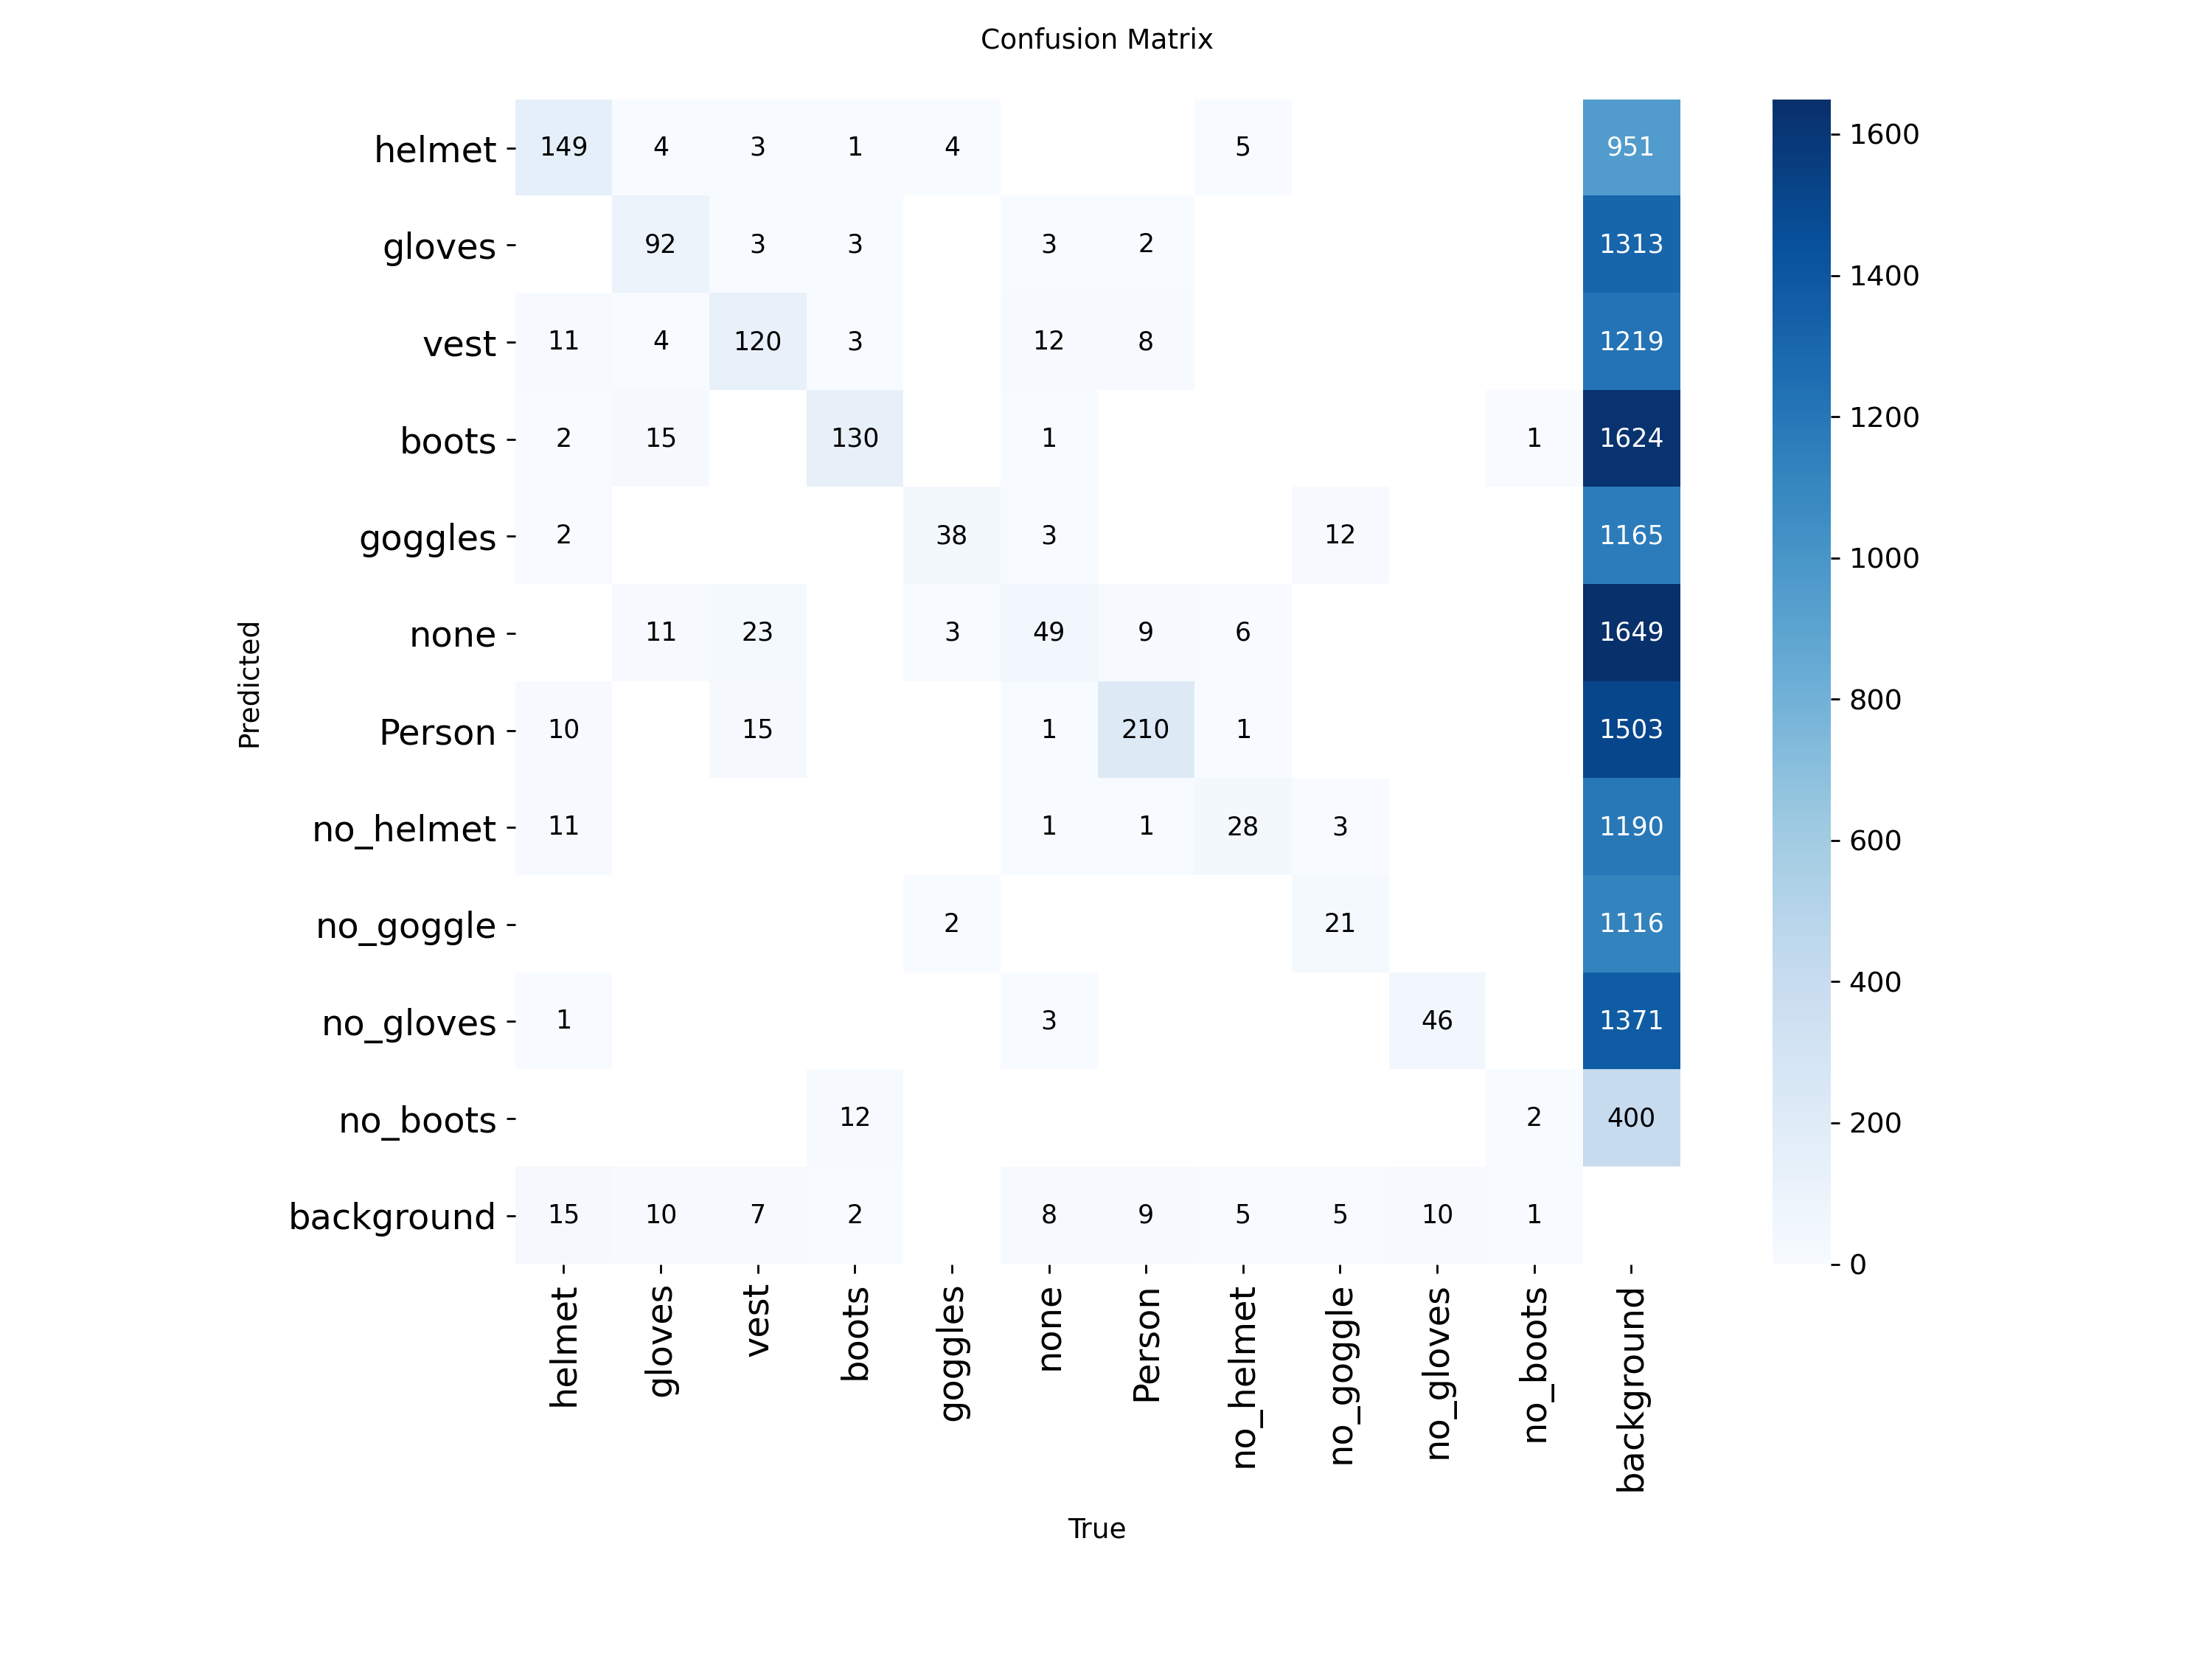

In [23]:
from IPython.display import Image

Image("/content/runs/detect/train/confusion_matrix.png")

Cell 18 – Display F1 Curve

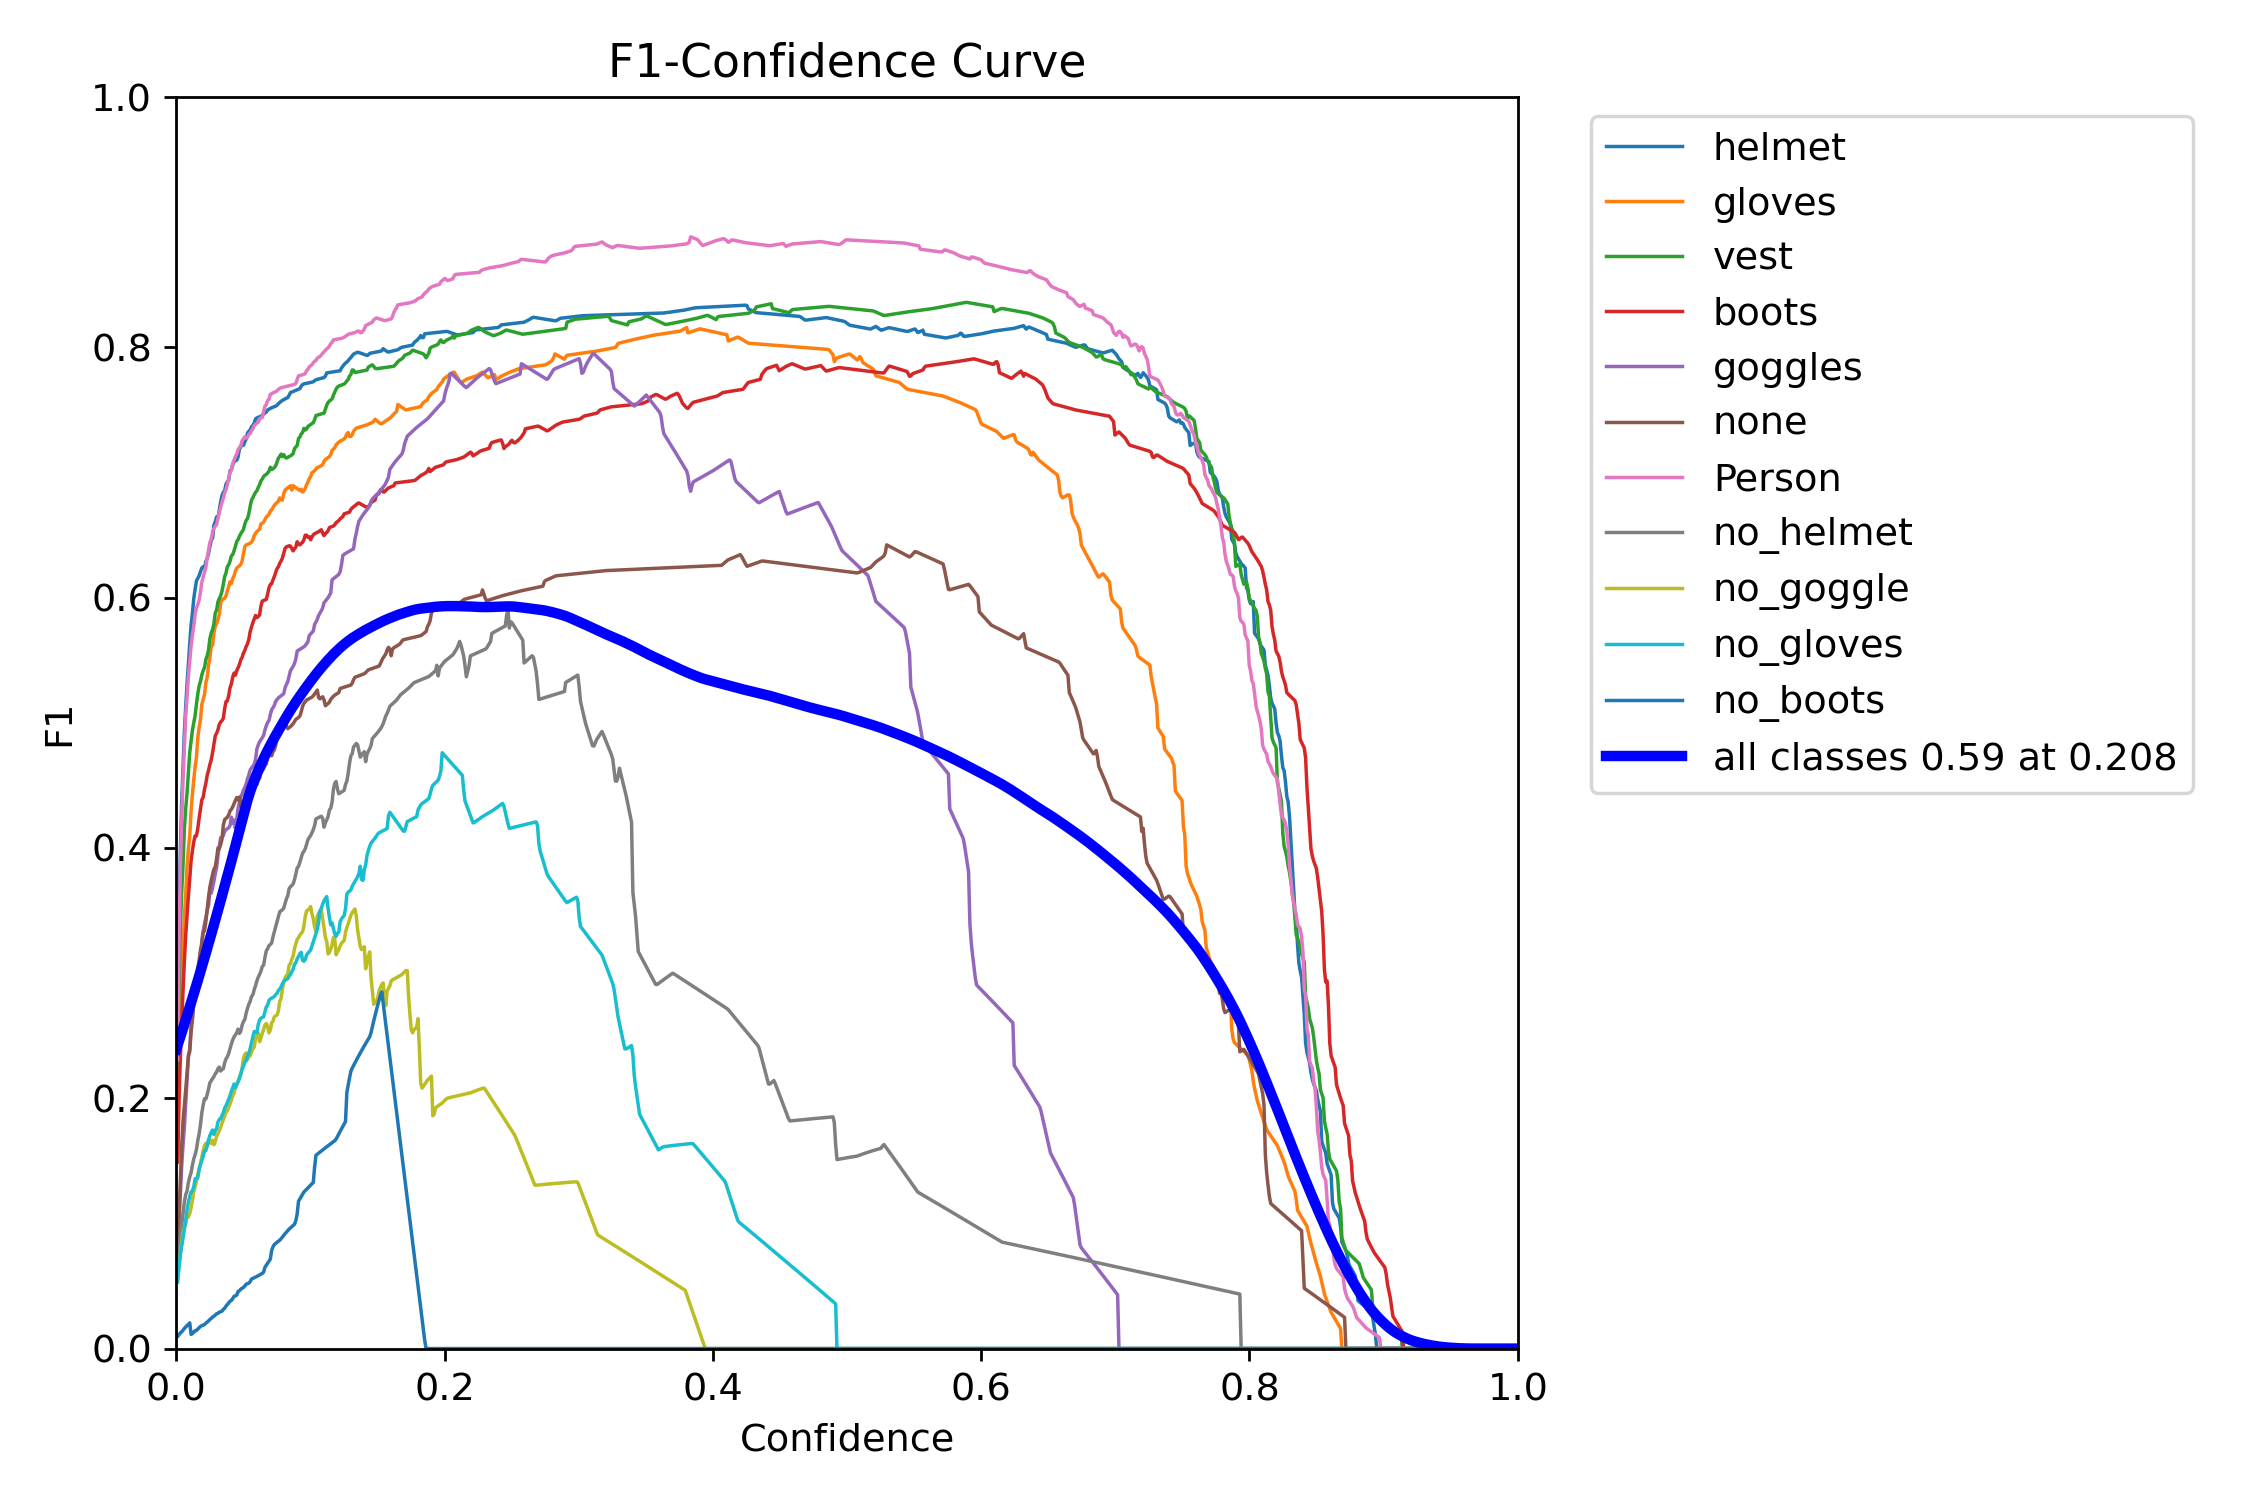

In [26]:
from IPython.display import Image

Image("/content/runs/detect/train/BoxF1_curve.png")

Cell 19 – Test on One Image

In [28]:
model.predict(

    source="/content/drive/MyDrive/test.jpg",

    conf=0.25,

    save=True
)


image 1/1 /content/drive/MyDrive/test.jpg: 512x640 1 helmet, 1 vest, 1 Person, 8.7ms
Speed: 3.3ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}
 obb: None
 orig_img: array([[[ 86,  93, 113],
         [ 87,  95, 118],
         [ 91,  98, 125],
         ...,
         [106, 106, 124],
         [ 98, 101, 122],
         [ 92,  95, 116]],
 
        [[ 88,  95, 115],
         [ 92,  98, 121],
         [ 96, 103, 130],
         ...,
         [105, 105, 123],
         [ 97, 100, 121],
         [ 92,  95, 116]],
 
        [[ 92,  96, 120],
         [ 96, 101, 126],
         [102, 106, 134],
         ...,
         [103, 103, 121],
         [ 95,  98, 119],
         [ 91,  94, 115]],
 
        ...,
 
        [[ 54,  69,  88],
         [ 58,  72,  94],
         [ 65,  77, 105],
         ...,
         [ 74,  57,  78],
         [ 73,

Cell 20 – Display Prediction

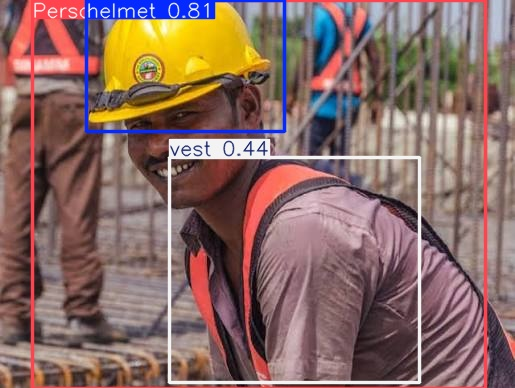

In [29]:
from IPython.display import Image

Image("/content/runs/detect/predict/test.jpg")

Cell 21 – Test Video

Upload a video:

test.mp4

Run:

In [30]:
results = model.predict(
    source="/content/drive/MyDrive/test.mp4",
    save=True,
    conf=0.25,
    stream=True
)

for r in results:
    pass


video 1/1 (frame 1/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 vest, 1 none, 2 Persons, 52.8ms
video 1/1 (frame 2/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 gloves, 1 vest, 1 none, 2 Persons, 11.1ms
video 1/1 (frame 3/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 vest, 1 none, 2 Persons, 35.0ms
video 1/1 (frame 4/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 gloves, 1 vest, 1 none, 2 Persons, 12.7ms
video 1/1 (frame 5/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 vest, 2 nones, 2 Persons, 11.6ms
video 1/1 (frame 6/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 gloves, 1 vest, 1 none, 2 Persons, 12.7ms
video 1/1 (frame 7/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 gloves, 1 vest, 1 none, 2 Persons, 11.6ms
video 1/1 (frame 8/252) /content/drive/MyDrive/test.mp4: 384x640 2 helmets, 1 gloves, 1 vest, 1 none, 2 Persons, 12.9ms
video 1/1 (frame 9/252) /content/drive/MyDrive/test.mp4: 384x640 2 h

Cell 22 – Final Performance Summary

In [37]:
metrics = best_model.val()

print("Precision :", round(metrics.box.mp,3))

print("Recall :", round(metrics.box.mr,3))

print("mAP@50 :", round(metrics.box.map50,3))

print("mAP@50-95 :", round(metrics.box.map,3))

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 81.3±52.7 MB/s, size: 102.9 KB)
val: Scanning /content/drive/MyDrive/Datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 31.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.2it/s 4.2s
                   all        143       1172      0.634      0.582      0.603      0.283
                helmet        107        201      0.806      0.816      0.825      0.432
                gloves         68        136      0.793      0.757      0.806      0.369
                  vest        109        171       0.81       0.83       0.86      0.508
                 boots         64        151      0.654      0.788      0.817      0.447
               goggles         44         47      0.732      0.809      0.812      0.368
             